In [30]:
import polars as pl
import os

# --- SECTION 1 : MERGE CLUSTER + TRANSACTIONS ---

# 1. Chargement du mapping (on récupère le résultat du clustering précédent)
# On utilise le fichier parquet généré à l'étape précédente pour la rapidité
cluster_map = pl.read_parquet("../data/processed/customer_segmentation_results.parquet").select(["user_id", "cluster"])

# 2. Chargement des transactions en mode Lazy (Scan)
# Cela évite de charger les 13M+ de lignes en RAM immédiatement
transactions = pl.scan_parquet("../data/processed/df_final_for_pipeline.parquet")

# 3. Join Cluster -> Transactions (Inner Join)
# On transforme cluster_map en lazy pour rester dans le graphe d'optimisation Polars
transactions_clustered = transactions.join(
    cluster_map.lazy(),
    on="user_id",
    how="inner"
)

# 4. Exécution et vérification (Collect)
# On jette un oeil aux premières lignes pour valider le merge
print("--- Aperçu des transactions segmentées ---")
display(transactions_clustered.head().collect())

# 5. Vérification de l'intégrité
# Est-ce qu'on a bien tous nos clusters représentés ?
check_clusters = transactions_clustered.group_by("cluster").agg(pl.len().alias("nb_lignes")).collect()
print("\n--- Distribution des lignes par cluster ---")
print(check_clusters)

transactions_clustered = transactions.join(
    cluster_map.lazy(),
    on="user_id",
    how="inner"
)

# 2. CRITIQUE : On écrit le résultat sur le disque en format Parquet
# Cela permet à la Section 2 (et aux suivantes) d'être ultra-rapides
output_path_s1 = "../data/processed/transactions_clustered.parquet"
os.makedirs(os.path.dirname(output_path_s1), exist_ok=True)

# On utilise .sink_parquet() pour les gros volumes (streaming vers le disque)
# ou .collect().write_parquet() si la RAM le permet
transactions_clustered.collect().write_parquet(output_path_s1)

print(f"✅ Section 1 terminée : Fichier créé ici -> {output_path_s1}")

--- Aperçu des transactions segmentées ---


order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department,nutriscore_grade,main_category,health_points,unit_price,order_value,nutri_score_num,nutri_missing,healthy,dept_mean_price,relative_price,cheap_product,cluster
i64,i64,i64,i64,i64,str,i64,i64,i64,f64,str,i64,i64,str,str,str,str,f32,f64,f64,f64,i64,i64,f64,f64,i8,i32
2,33120,1,1,202279,"""prior""",3,5,9,8.0,"""Organic Egg Whites""",86,16,"""eggs""","""dairy eggs""","""UNKNOWN""","""unknown""",null,3.04,32.06,4.0,1,1,3.58183,0.848728,1,2
2,28985,2,1,202279,"""prior""",3,5,9,8.0,"""Michigan Organic Kale""",83,4,"""fresh vegetables""","""produce""","""UNKNOWN""","""unknown""",null,4.61,32.06,4.0,1,1,2.42471,1.901258,0,2
2,9327,3,0,202279,"""prior""",3,5,9,8.0,"""Garlic Powder""",104,13,"""spices seasonings""","""pantry""","""UNKNOWN""","""unknown""",null,5.82,32.06,4.0,1,1,4.433397,1.312763,0,2
2,45918,4,1,202279,"""prior""",3,5,9,8.0,"""Coconut Butter""",19,13,"""oils vinegars""","""pantry""","""D""","""en:null""",2.0,4.8,32.06,2.0,0,0,4.433397,1.082691,0,2
2,30035,5,0,202279,"""prior""",3,5,9,8.0,"""Natural Sweetener""",17,13,"""baking ingredients""","""pantry""","""UNKNOWN""","""en:undefined""",null,2.19,32.06,4.0,1,1,4.433397,0.493978,1,2



--- Distribution des lignes par cluster ---
shape: (3, 2)
┌─────────┬───────────┐
│ cluster ┆ nb_lignes │
│ ---     ┆ ---       │
│ i32     ┆ u32       │
╞═════════╪═══════════╡
│ 0       ┆ 20719057  │
│ 1       ┆ 3799667   │
│ 2       ┆ 9300382   │
└─────────┴───────────┘
✅ Section 1 terminée : Fichier créé ici -> ../data/processed/transactions_clustered.parquet


In [31]:
# --- SECTION 2  ---

# 1. Chargement des transactions clusterisées (Lazy)
transactions_clustered = pl.scan_parquet("../data/processed/transactions_clustered.parquet")

# 2. Agrégation de base : Cluster + Produit
# On calcule les métriques de volume, fidélité et valeur
product_cluster_stats = (
    transactions_clustered
    .group_by(["cluster", "product_id"])
    .agg([
        pl.col("user_id").n_unique().alias("users"),
        pl.col("order_id").n_unique().alias("baskets"),
        pl.len().alias("orders"), # Nombre total de lignes (fréquence brute)
        pl.col("reordered").mean().alias("reorder_rate"),
        pl.col("order_value").sum().alias("spend"),
        pl.col("healthy").mean().alias("healthy_score"),
        pl.col("cheap_product").mean().alias("price_score")
    ])
)

# 3. Calcul des totaux par Cluster pour la normalisation
# On a besoin du nombre total de paniers et du CA total par cluster
cluster_totals = (
    transactions_clustered
    .group_by("cluster")
    .agg([
        pl.col("order_id").n_unique().alias("cluster_total_baskets"),
        pl.col("order_value").sum().alias("cluster_total_spend"),
        pl.col("user_id").n_unique().alias("cluster_total_users")
    ])
)

# 4. Enrichissement : Calcul de basket_presence, spend_share et penetration
product_cluster_stats = (
    product_cluster_stats
    .join(cluster_totals, on="cluster")
    .with_columns([
        # Probabilité de présence dans un panier du segment
        (pl.col("baskets") / pl.col("cluster_total_baskets")).alias("basket_presence"),

        # Part de marché du produit au sein du segment
        (pl.col("spend") / pl.col("cluster_total_spend")).alias("spend_share"),

        # Pénétration client (Reach relatif au cluster)
        (pl.col("users") / pl.col("cluster_total_users")).alias("penetration")
    ])
)

# 5. Exécution et Sauvegarde intermédiaire
# On collect() car c'est la base pour les prochaines étapes de classification
df_stats_final = product_cluster_stats.collect()

print("--- Aperçu des Statistiques Produit x Cluster ---")
display(df_stats_final.sort(["cluster", "basket_presence"], descending=True).head(10))

# Export pour la section suivante
df_stats_final.write_parquet("../data/processed/product_cluster_stats.parquet")

--- Aperçu des Statistiques Produit x Cluster ---


cluster,product_id,users,baskets,orders,reorder_rate,spend,healthy_score,price_score,cluster_total_baskets,cluster_total_spend,cluster_total_users,basket_presence,spend_share,penetration
i32,i64,u32,u32,u32,f64,f64,f64,f64,u32,f64,u32,f64,f64,f64
2,24852,33292,117384,117384,0.716384,8.4167e6,1.0,1.0,701132,7.7836e8,79240,0.167421,0.010813,0.420141
2,13176,21524,66297,66297,0.67534,4.9765e6,1.0,0.0,701132,7.7836e8,79240,0.094557,0.006394,0.27163
2,21903,19919,49954,49954,0.601253,3.7014e6,1.0,0.0,701132,7.7836e8,79240,0.071248,0.004755,0.251376
2,21137,20733,48772,48772,0.5749,3.6468e6,1.0,1.0,701132,7.7836e8,79240,0.069562,0.004685,0.261648
2,47766,18241,47904,47904,0.619218,3.4925e6,1.0,0.0,701132,7.7836e8,79240,0.068324,0.004487,0.230199
2,47626,20753,45282,45282,0.541694,3.4431e6,1.0,0.0,701132,7.7836e8,79240,0.064584,0.004423,0.261901
2,47209,16302,41466,41466,0.606859,3.1912e6,1.0,0.0,701132,7.7836e8,79240,0.059142,0.0041,0.205729
2,26209,19259,38296,38296,0.497102,2.9432e6,1.0,1.0,701132,7.7836e8,79240,0.05462,0.003781,0.243046
2,16797,16827,36333,36333,0.536867,2.8606e6,1.0,0.0,701132,7.7836e8,79240,0.05182,0.003675,0.212355


In [32]:
# --- SECTION 3  ---

# 1. Chargement des statistiques produits (Lazy)
product_cluster_stats = pl.scan_parquet("../data/processed/product_cluster_stats.parquet")

# 2. Calcul des seuils (Quantiles) dynamiques PAR CLUSTER
# On définit ce qui est "élevé" ou "faible" au sein de chaque univers client
quantiles = (
    product_cluster_stats
    .group_by("cluster")
    .agg([
        pl.col("basket_presence").quantile(0.25).alias("reach_q25"),
        pl.col("basket_presence").quantile(0.75).alias("reach_q75"),
        pl.col("reorder_rate").quantile(0.25).alias("reorder_q25"),
        pl.col("reorder_rate").quantile(0.75).alias("reorder_q75")
    ])
)

# 3. Join et Attribution des Rôles
# On applique la logique de l'espace 2D Diffusion vs Fidélité
pcs = (
    product_cluster_stats
    .join(quantiles, on="cluster")
    .with_columns(
        role = pl.when(
            (pl.col("basket_presence") >= pl.col("reach_q75")) &
            (pl.col("reorder_rate") >= pl.col("reorder_q75"))
        ).then(pl.lit("core"))

        .when(
            (pl.col("basket_presence") >= pl.col("reach_q75")) &
            (pl.col("reorder_rate") < pl.col("reorder_q25"))
        ).then(pl.lit("opportunistic"))

        .when(
            (pl.col("basket_presence") < pl.col("reach_q25")) &
            (pl.col("reorder_rate") >= pl.col("reorder_q75"))
        ).then(pl.lit("niche"))

        # On ajoute une nuance pour le "Filler" (optionnel mais utile) :
        # faible présence et faible fidélité
        .when(
            (pl.col("basket_presence") < pl.col("reach_q25")) &
            (pl.col("reorder_rate") < pl.col("reorder_q25"))
        ).then(pl.lit("filler"))

        .otherwise(pl.lit("companion"))
    )
)

# 4. Nettoyage : On ne garde que les colonnes essentielles pour le Golden Basket
final_roles = pcs.select([
    "cluster", "product_id", "role",
    "basket_presence", "reorder_rate", "penetration", "spend_share"
])

# 5. Exécution et Sauvegarde
df_roles = final_roles.collect()
df_roles.write_parquet("../data/processed/product_role_by_cluster.parquet")

# --- VÉRIFICATIONS ---

print("--- Distribution des rôles par cluster ---")
distribution = df_roles.group_by(["cluster", "role"]).len().sort(["cluster", "role"])
print(distribution)

# Visualisation rapide du Top Core du Cluster 0 (Premium)
print("\n--- Top 5 CORE Products - Cluster 0 (Premium) ---")
display(df_roles.filter((pl.col("cluster") == 0) & (pl.col("role") == "core"))
        .sort("basket_presence", descending=True).head(5))

--- Distribution des rôles par cluster ---
shape: (13, 3)
┌─────────┬───────────────┬───────┐
│ cluster ┆ role          ┆ len   │
│ ---     ┆ ---           ┆ ---   │
│ i32     ┆ str           ┆ u32   │
╞═════════╪═══════════════╪═══════╡
│ 0       ┆ companion     ┆ 34091 │
│ 0       ┆ core          ┆ 5727  │
│ 0       ┆ filler        ┆ 7457  │
│ 0       ┆ niche         ┆ 534   │
│ 0       ┆ opportunistic ┆ 350   │
│ …       ┆ …             ┆ …     │
│ 2       ┆ companion     ┆ 34301 │
│ 2       ┆ core          ┆ 5184  │
│ 2       ┆ filler        ┆ 7989  │
│ 2       ┆ niche         ┆ 1161  │
│ 2       ┆ opportunistic ┆ 353   │
└─────────┴───────────────┴───────┘

--- Top 5 CORE Products - Cluster 0 (Premium) ---


cluster,product_id,role,basket_presence,reorder_rate,penetration,spend_share
i32,i64,str,f64,f64,f64,f64
0,24852,"""core""",0.172805,0.913942,0.537523,0.01293
0,13176,"""core""",0.144187,0.902577,0.507738,0.011177
0,21137,"""core""",0.105435,0.860604,0.531235,0.008435
0,21903,"""core""",0.090907,0.856995,0.469894,0.007398
0,47209,"""core""",0.087691,0.86786,0.418832,0.007268


In [51]:
# --- SECTION 4 : GÉNÉRATION DU GOLDEN BASKET PERSONNALISÉ ---

# 1. PRÉPARATION DES DONNÉES & SCORES ADAPTATIFS
pcs_lazy = pl.scan_parquet("../data/processed/product_role_by_cluster.parquet")
stats_lazy = pl.scan_parquet("../data/processed/product_cluster_stats.parquet").select([
    "cluster", "product_id", "healthy_score", "price_score"
])
# On récupère les noms de personas pour appliquer les règles métiers
df_personas = pl.read_csv("../data/processed/df_personas_for_goldenbasket.csv").select([
    pl.col("cluster_id").alias("cluster"),
    "persona"
])

# Jointure initiale
pcs_lazy = pcs_lazy.join(stats_lazy, on=["cluster", "product_id"]).join(df_personas.lazy(), on="cluster")

# Application de la LOGIQUE MÉTIER par Persona
# On définit les poids : (Price, Health, Popularity)
pcs_lazy = pcs_lazy.with_columns(
    gb_score = pl.when(pl.col("persona") == "The Premium Healths")
    .then(0.1 * pl.col("price_score") + 0.7 * pl.col("healthy_score") + 0.2 * pl.col("basket_presence"))

    .when(pl.col("persona") == "The Daily Economizers")
    .then(0.7 * pl.col("price_score") + 0.1 * pl.col("healthy_score") + 0.2 * pl.col("basket_presence"))

    .when(pl.col("persona") == "The Budget-Healthy Mix")
    .then(0.4 * pl.col("price_score") + 0.4 * pl.col("healthy_score") + 0.2 * pl.col("basket_presence"))

    .otherwise(0.5 * pl.col("price_score") + 0.5 * pl.col("basket_presence"))
)

# Optionnel : Boost "Gros Formats" pour les Daily Economizers (si vous avez les noms de produits ici)
# Note : Si product_name n'est pas dans pcs_lazy, cette étape peut être faite après la jointure meta en section 5.

pcs_df = pcs_lazy.collect()

# 2. CALCUL DES CONTRAINTES DE TAILLE
transactions_clustered = pl.scan_parquet("../data/processed/transactions_clustered.parquet")
cluster_constraints = (
    transactions_clustered
    .group_by("cluster")
    .agg([
        pl.col("order_id").n_unique().alias("total_baskets"),
        pl.len().alias("total_items")
    ])
    .with_columns(
        limit_size = ((pl.col("total_items") / pl.col("total_baskets")) + 1).round(0).cast(pl.Int32)
    )
).collect()

# 3. LOGIQUE DE SÉLECTION DYNAMIQUE
golden_basket_list = []
for c_info in cluster_constraints.to_dicts():
    c_id = c_info['cluster']
    c_limit = c_info['limit_size']

    # Quotas par rôles
    n_core = max(2, int(c_limit * 0.4))
    n_comp = max(2, int(c_limit * 0.3))
    n_niche = max(1, int(c_limit * 0.2))
    n_opp = 1

    for role_name, n_limit in zip(["core", "companion", "niche", "opportunistic"], [n_core, n_comp, n_niche, n_opp]):
        filtered = (
            pcs_df.filter((pl.col("cluster") == c_id) & (pl.col("role") == role_name))
            .sort("gb_score", descending=True)
            .head(n_limit)
        )
        golden_basket_list.append(filtered)

# 4. ASSEMBLAGE & ENRICHISSEMENT FINAL
golden_basket = pl.concat(golden_basket_list)

golden_basket_final = (
    golden_basket.lazy()
    .with_columns(
        rank_in_golden = pl.col("gb_score").rank(descending=True).over("cluster")
    )
).collect()

# 5. EXPORT
golden_basket_final.write_parquet("../data/processed/golden_basket_segmented.parquet")

print("✅ Section 4 optimisée : Scoring différencié par profil client appliqué.")

✅ Section 4 optimisée : Scoring différencié par profil client appliqué.


In [52]:
# --- VALIDATION 1 : Profils Healthy/Price ---
# On utilise le nom correct : golden_basket_final
validation_persona = golden_basket_final.group_by("cluster").agg([
    pl.col("healthy_score").mean().alias("avg_healthy_in_GB"),
    pl.col("price_score").mean().alias("avg_price_sensitivity_in_GB")
])
print("--- Validation des Personas (Moyennes GB) ---")
print(validation_persona)

# --- VALIDATION 2 : Diversité des Rôles ---
diversity_check = golden_basket_final.group_by(["cluster", "role"]).len().sort("cluster")
print("\n--- Diversité des rôles par panier ---")
print(diversity_check)

--- Validation des Personas (Moyennes GB) ---
shape: (3, 3)
┌─────────┬───────────────────┬─────────────────────────────┐
│ cluster ┆ avg_healthy_in_GB ┆ avg_price_sensitivity_in_GB │
│ ---     ┆ ---               ┆ ---                         │
│ i32     ┆ f64               ┆ f64                         │
╞═════════╪═══════════════════╪═════════════════════════════╡
│ 1       ┆ 1.0               ┆ 1.0                         │
│ 0       ┆ 1.0               ┆ 1.0                         │
│ 2       ┆ 1.0               ┆ 1.0                         │
└─────────┴───────────────────┴─────────────────────────────┘

--- Diversité des rôles par panier ---
shape: (11, 3)
┌─────────┬───────────────┬─────┐
│ cluster ┆ role          ┆ len │
│ ---     ┆ ---           ┆ --- │
│ i32     ┆ str           ┆ u32 │
╞═════════╪═══════════════╪═════╡
│ 0       ┆ niche         ┆ 2   │
│ 0       ┆ core          ┆ 4   │
│ 0       ┆ opportunistic ┆ 1   │
│ 0       ┆ companion     ┆ 3   │
│ 1       ┆ niche    

In [53]:
# --- SECTION 5 ---
# On récupère le Golden Basket déjà calculé et scoré en Section 4
# (Assure-toi de l'avoir sauvegardé en fin de Section 4)
df_gb_core = pl.scan_parquet("../data/processed/golden_basket_segmented.parquet")

# Couche Persona : Labels clairs
df_personas = pl.read_csv("../data/processed/df_personas_for_goldenbasket.csv").select(["cluster_id", "persona"])

# Couche Metadata : Noms et catégories
df_meta = pl.scan_parquet("../data/processed/df_final_for_pipeline.parquet").select([
    "product_id", "product_name", "aisle", "department"
]).unique()

# --- 2. ASSEMBLAGE FINAL (JOINTS) ---

# Ici, on enrichit simplement le travail de la Section 4
golden_basket_final = (
    df_gb_core
    .join(df_personas.lazy(), left_on="cluster", right_on="cluster_id")
    .join(df_meta, on="product_id")
    .select([
        "cluster",
        "persona",
        "product_id",
        "product_name",
        "role",
        "gb_score",
        "rank_in_golden", # On garde le rang de la section 4
        "aisle",
        "department",
        "basket_presence",
        "reorder_rate",
        "spend_share"
    ])
    .sort(["cluster", "rank_in_golden"])
)

# --- 3. EXPORT DES LIVRABLES STRATÉGIQUES ---

output_dir = "../data/outputs/"
os.makedirs(output_dir, exist_ok=True)

# Livrable 1: L'Artefact Golden Basket (Le Graal pour la recommandation)
final_artifact = golden_basket_final.collect()
final_artifact.write_parquet(f"{output_dir}golden_basket_segmented_final.parquet")
final_artifact.write_csv(f"{output_dir}golden_basket_segmented_final.csv") # Version Excel-friendly

# Livrable 2: Mapping complet des rôles (pour le merchandising)
# On récupère les rôles de tous les produits, pas seulement du top 8
pl.read_parquet("../data/processed/product_role_by_cluster.parquet").write_parquet(f"{output_dir}product_role_mapping.parquet")

print(f"🚀 Artefacts finaux prêts dans {output_dir}")
print(f"📦 Taille du Golden Basket : {final_artifact.shape[0]} recommandations.")

🚀 Artefacts finaux prêts dans ../data/outputs/
📦 Taille du Golden Basket : 27 recommandations.


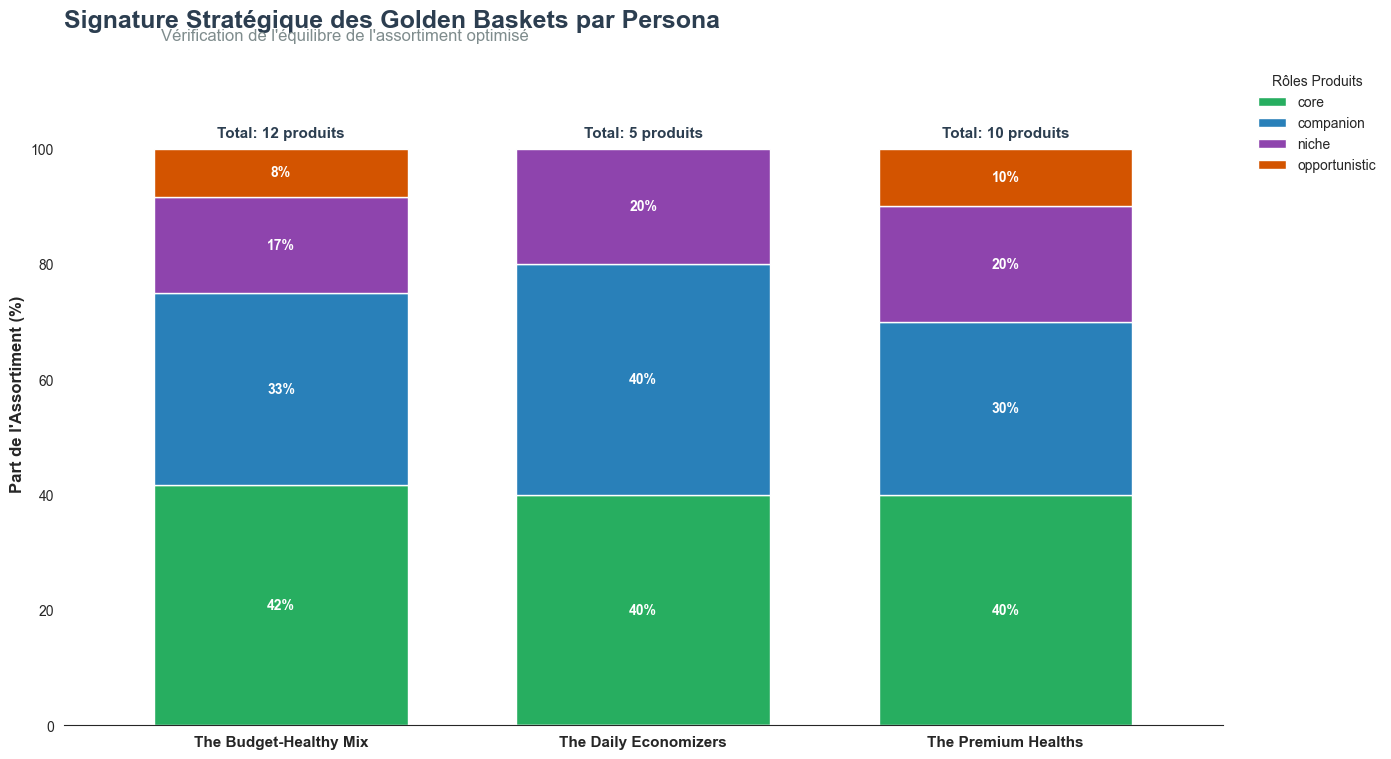

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. RÉCUPÉRATION DES DONNÉES FRAICHES
# On s'assure d'utiliser le résultat de la nouvelle Section 4
df_viz = final_artifact.to_pandas()

# 2. PRÉPARATION : Calcul des parts relatives (%)
# On groupe par Persona et par Rôle pour voir la structure du panier
role_counts = df_viz.groupby(['persona', 'role']).size().unstack().fillna(0)
role_perc = role_counts.div(role_counts.sum(axis=1), axis=0) * 100

# 3. CONFIGURATION VISUELLE
plt.figure(figsize=(14, 8))
sns.set_style("white")

# Couleurs sémantiques (Vert pour le Core, Bleu pour le reste)
colors_map = {
    'core': '#27ae60',          # Vert succès
    'companion': '#2980b9',     # Bleu
    'niche': '#8e44ad',         # Violet
    'opportunistic': '#d35400', # Orange
    'filler': '#95a5a6'         # Gris
}

# Ordre logique des rôles dans la pile
ordered_roles = [r for r in ['core', 'companion', 'niche', 'opportunistic', 'filler'] if r in role_perc.columns]
role_perc = role_perc[ordered_roles]

# 4. PLOT
ax = role_perc.plot(kind='bar', stacked=True,
                    color=[colors_map[c] for c in ordered_roles],
                    ax=plt.gca(), width=0.7, edgecolor='white', linewidth=1)

# 5. ANNOTATIONS (Pourcentages au centre des segments)
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5: # On n'affiche que si le segment est assez grand
        ax.text(p.get_x() + width/2, p.get_y() + height/2, f'{height:.0f}%',
                ha='center', va='center', color='white', fontweight='bold', fontsize=10)

# Affichage du nombre total de produits au-dessus de chaque barre
totals = role_counts.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(i, 102, f"Total: {int(total)} produits",
            ha='center', fontweight='bold', color='#2c3e50', fontsize=11)

# 6. HABILLAGE FINAL
plt.title("Signature Stratégique des Golden Baskets par Persona\n",
          fontsize=18, fontweight='bold', loc='left', color='#2c3e50')
plt.suptitle("Vérification de l'équilibre de l'assortiment optimisé",
             fontsize=12, x=0.25, y=0.92, color='#7f8c8d')

plt.ylabel("Part de l'Assortiment (%)", fontsize=12, fontweight='bold')
plt.xlabel("")
plt.xticks(rotation=0, fontsize=11, fontweight='bold')
plt.ylim(0, 115)

# Légende élégante
plt.legend(title="Rôles Produits", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=10)

sns.despine(left=True)
plt.tight_layout()
plt.show()

In [59]:
import polars as pl
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Préparation des métriques brutes par Cluster
# On calcule les moyennes réelles pour chaque axe souhaité
radar_metrics = (
    pl.scan_parquet("../data/processed/transactions_clustered.parquet")
    .group_by("cluster")
    .agg([
        pl.col("reordered").mean().alias("Fidélité"),
        pl.col("healthy").mean().alias("Santé"),
        pl.col("cheap_product").mean().alias("Économie"),
        pl.col("order_value").mean().alias("Budget Panier"),
        pl.col("product_id").count().over("order_id").mean().alias("Volume d'achat")
    ])
    .collect()
)

# 2. Ajout des noms de Personas
df_personas = pl.read_csv("../data/processed/df_personas_for_goldenbasket.csv").select(["cluster_id", "persona"])
radar_full = radar_metrics.join(df_personas, left_on="cluster", right_on="cluster_id")

# 3. Normalisation (Min-Max) pour le rendu visuel
df_radar_raw = radar_full.to_pandas()
categories = [c for c in df_radar_raw.columns if c not in ["cluster", "persona"]]

for col in categories:
    col_min = df_radar_raw[col].min()
    col_max = df_radar_raw[col].max()

    if col_max - col_min != 0:
        # L'astuce est ici : on commence à 0.1 pour ne pas avoir de point au centre
        df_radar_raw[col] = 0.1 + (df_radar_raw[col] - col_min) / (col_max - col_min) * 0.9
    else:
        df_radar_raw[col] = 0.5

# On ne garde que les colonnes finales
df_radar = df_radar_raw[["persona"] + categories]

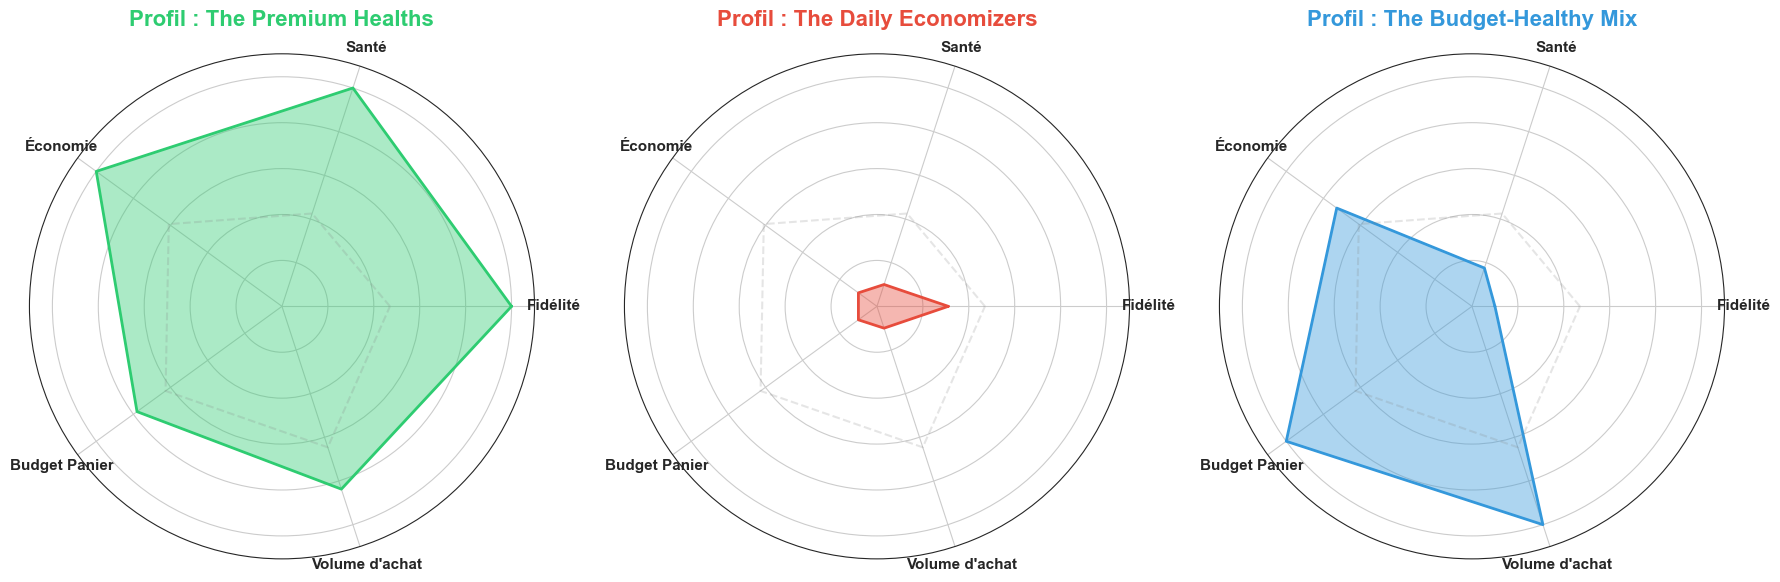

In [60]:
import matplotlib.pyplot as plt
import numpy as np

# --- Ton code de visualisation avec df_radar maintenant défini ---
categories = list(df_radar)[1:]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

# On adapte le nombre de colonnes au nombre de personas (si tu en as plus que 3)
n_personas = len(df_radar)
fig, axes = plt.subplots(1, n_personas, figsize=(6 * n_personas, 6), subplot_kw=dict(polar=True))

# Palette de couleurs étendue au cas où
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f1c40f', '#9b59b6']

for i, persona in enumerate(df_radar['persona']):
    ax = axes[i] if n_personas > 1 else axes
    values = df_radar.iloc[i].drop('persona').values.flatten().tolist()
    values += values[:1]

    # Silhouette
    ax.plot(angles, values, color=colors[i % len(colors)], linewidth=2)
    ax.fill(angles, values, color=colors[i % len(colors)], alpha=0.4)

    # Ombre grise (Moyenne globale)
    mean_values = df_radar.drop('persona', axis=1).mean().values.flatten().tolist()
    mean_values += mean_values[:1]
    ax.plot(angles, mean_values, color='grey', alpha=0.2, linestyle='--')

    ax.set_title(f"Profil : {persona}", size=16, color=colors[i % len(colors)], fontweight='bold', pad=20)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=11, fontweight='bold')

    # On retire les labels de l'axe Y pour plus de clarté
    ax.set_yticklabels([])
    ax.set_ylim(0, 1.1) # On laisse un peu d'air au sommet

plt.tight_layout()
plt.show()

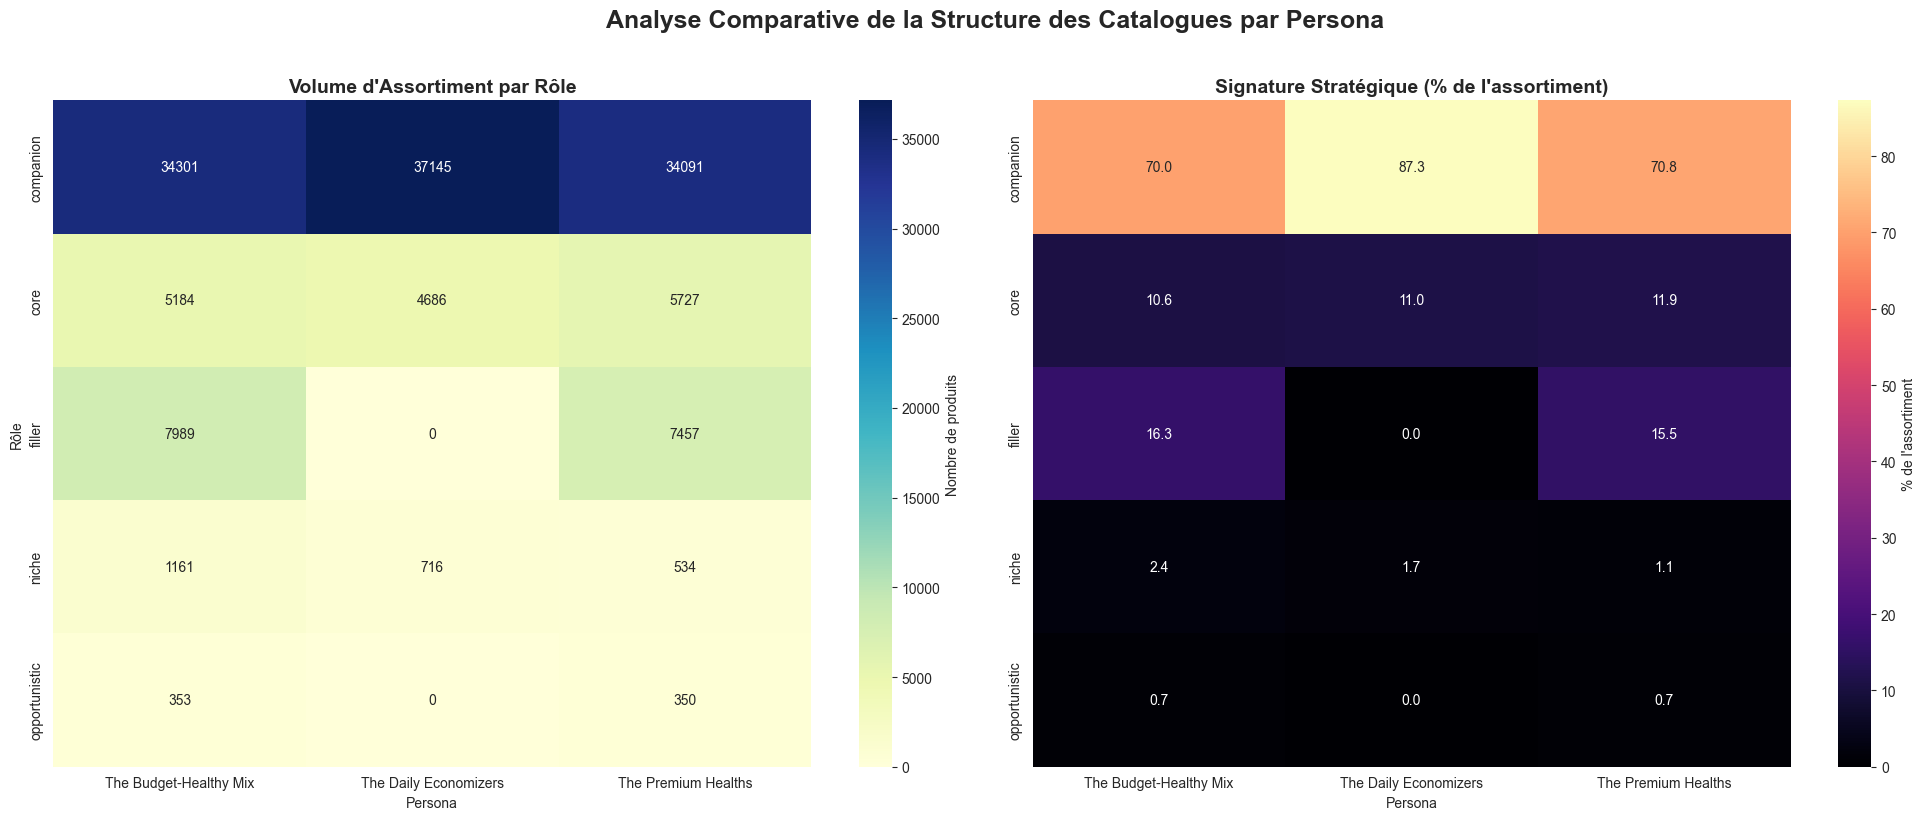

In [68]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chargement des données
df_roles = pd.read_parquet("../data/outputs/product_role_mapping.parquet")
df_personas = pd.read_csv("../data/outputs/persona_profiling.csv")

# Jointure pour avoir les noms des personas
df_full = df_roles.merge(df_personas, left_on="cluster", right_on="cluster_id")

# 2. Préparation des données (Pivot Table)
heatmap_abs = df_full.groupby(['role', 'persona']).size().unstack(fill_value=0)

# Version normalisée (%)
heatmap_rel = heatmap_abs.div(heatmap_abs.sum(axis=0), axis=1) * 100

# 3. Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# A. Heatmap des volumes bruts
sns.heatmap(heatmap_abs, annot=True, fmt="d", cmap="YlGnBu", ax=ax1, cbar_kws={'label': 'Nombre de produits'})
ax1.set_title("Volume d'Assortiment par Rôle", fontsize=14, fontweight='bold')
ax1.set_xlabel("Persona")
ax1.set_ylabel("Rôle")

# B. Heatmap des densités relatives (%)
# FIX : 'magma' en minuscule pour éviter le KeyError
sns.heatmap(heatmap_rel, annot=True, fmt=".1f", cmap="magma", ax=ax2, cbar_kws={'label': '% de l\'assortiment'})
ax2.set_title("Signature Stratégique (% de l'assortiment)", fontsize=14, fontweight='bold')
ax2.set_xlabel("Persona")
ax2.set_ylabel("")

plt.suptitle("Analyse Comparative de la Structure des Catalogues par Persona", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()